In [36]:
from pathlib import Path
from scipy.io import loadmat
from scipy.signal import resample
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import hamming_loss

In [37]:
file = open("../../datasets/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt")
lines = file.readlines()

processedList = []

for i, line in enumerate(lines):
    try:
        line = line.split(",")
        last = line[5].split(";")[0]
        last = last.strip()
        if last == "":
            break
        temp = [line[0], line[1], line[2], line[3], line[4], last]
        processedList.append(temp)
    except Exception:
        print("Error at line number: ", i)

Error at line number:  281873
Error at line number:  281874
Error at line number:  281875


In [38]:
processedList[:100]

[['33', 'Jogging', '49105962326000', '-0.6946377', '12.680544', '0.50395286'],
 ['33', 'Jogging', '49106062271000', '5.012288', '11.264028', '0.95342433'],
 ['33', 'Jogging', '49106112167000', '4.903325', '10.882658', '-0.08172209'],
 ['33', 'Jogging', '49106222305000', '-0.61291564', '18.496431', '3.0237172'],
 ['33', 'Jogging', '49106332290000', '-1.1849703', '12.108489', '7.205164'],
 ['33', 'Jogging', '49106442306000', '1.3756552', '-2.4925237', '-6.510526'],
 ['33', 'Jogging', '49106542312000', '-0.61291564', '10.56939', '5.706926'],
 ['33', 'Jogging', '49106652389000', '-0.50395286', '13.947236', '7.0553403'],
 ['33', 'Jogging', '49106762313000', '-8.430995', '11.413852', '5.134871'],
 ['33', 'Jogging', '49106872299000', '0.95342433', '1.3756552', '1.6480621'],
 ['33', 'Jogging', '49106982315000', '-8.19945', '19.57244', '2.7240696'],
 ['33', 'Jogging', '49107092330000', '1.4165162', '5.7886477', '2.982856'],
 ['33', 'Jogging', '49107202316000', '-1.879608', '-2.982856', '-0.2996

In [39]:
columns = ["user", "activity", "time", "x", "y", "z"]
data = pd.DataFrame(data=processedList, columns=columns)
data.head()

,user,activity,time,x,y,z
0,33,Jogging,49105962326000,-0.6946377,12.680544,0.50395286
1,33,Jogging,49106062271000,5.012288,11.264028,0.95342433
2,33,Jogging,49106112167000,4.903325,10.882658,-0.08172209
3,33,Jogging,49106222305000,-0.61291564,18.496431,3.0237172
4,33,Jogging,49106332290000,-1.1849703,12.108489,7.205164


In [40]:
data.shape

(343416, 6)

In [41]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 343416 entries, 0 to 343415
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   user      343416 non-null  str  
 1   activity  343416 non-null  str  
 2   time      343416 non-null  str  
 3   x         343416 non-null  str  
 4   y         343416 non-null  str  
 5   z         343416 non-null  str  
dtypes: str(6)
memory usage: 15.7 MB


In [42]:
data.isnull().sum()

user        0
activity    0
time        0
x           0
y           0
z           0
dtype: int64

In [43]:
data["x"] = data["x"].astype("float")
data["y"] = data["y"].astype("float")
data["z"] = data["z"].astype("float")

In [44]:
Fs = 20
activities = data["activity"].value_counts().index
activities

Index(['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing'], dtype='str', name='activity')

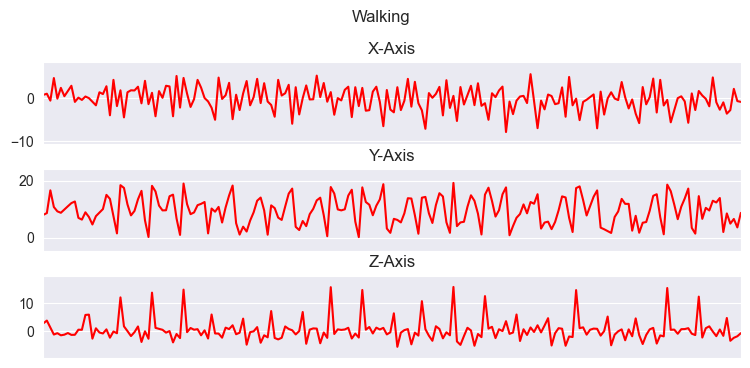

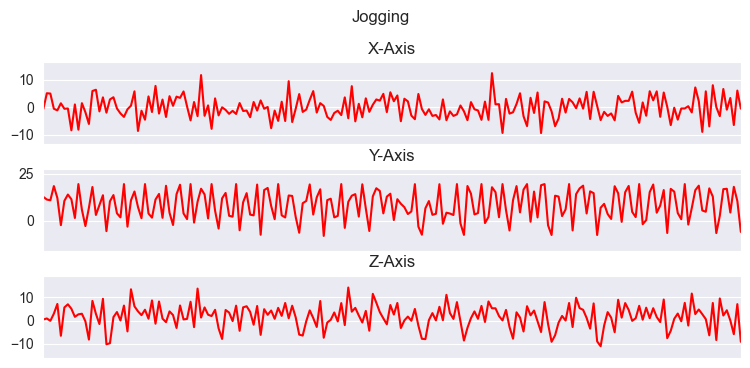

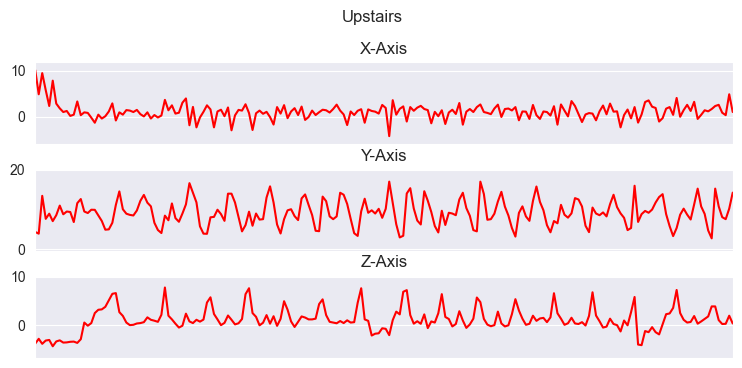

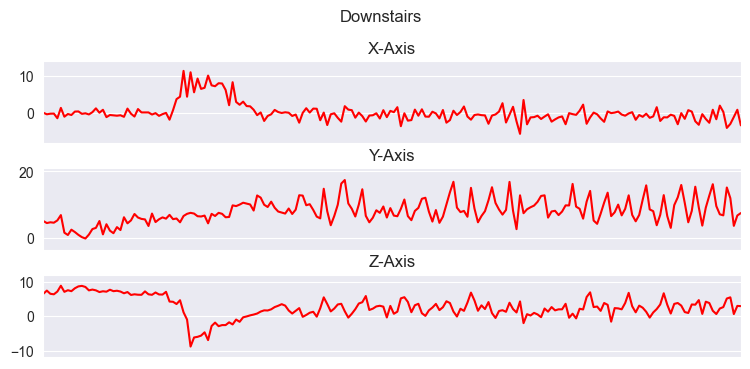

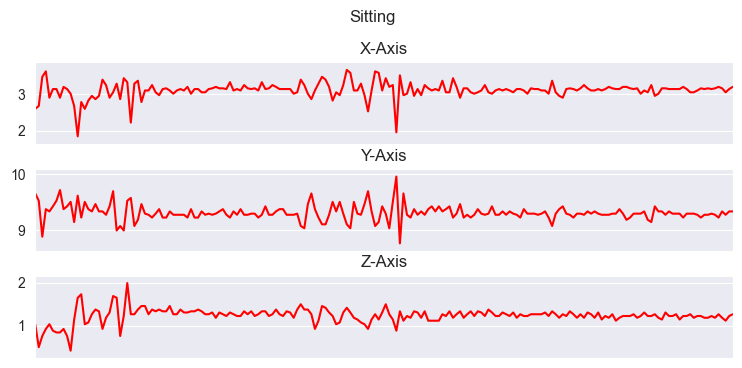

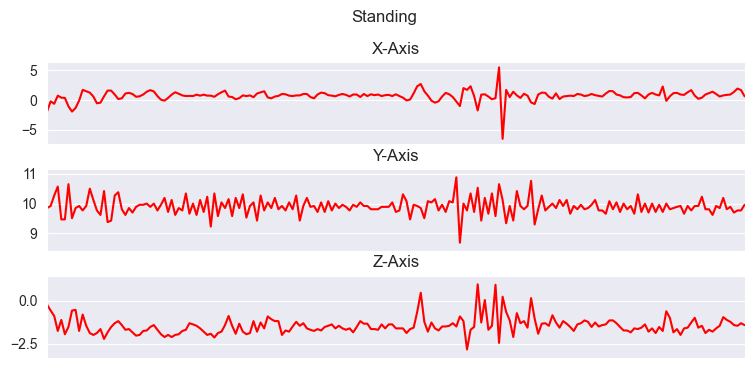

In [45]:
def plot_activity(activity, data):
    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(9, 4), sharex=True)
    plot_axis(ax0, data["time"], data["x"], "X-Axis")
    plot_axis(ax1, data["time"], data["y"], "Y-Axis")
    plot_axis(ax2, data["time"], data["z"], "Z-Axis")
    plt.subplots_adjust(hspace=0.3)
    fig.suptitle(activity)
    plt.subplots_adjust(top=0.85)
    plt.show()


def plot_axis(ax, x, y, title):
    ax.plot(x, y, "r")
    ax.set_title(title)
    ax.xaxis.set_visible(False)
    ax.set_ylim([min(y) - np.std(y), max(y) + np.std(y)])
    ax.set_xlim([min(x), max(x)])
    ax.grid(True)


for activity in activities:
    data_for_plot = data[(data["activity"] == activity)][: Fs * 10]
    plot_activity(activity, data_for_plot)

In [46]:
df = data.drop(["user", "time"], axis=1).copy()
df.head()

,activity,x,y,z
0,Jogging,-0.694638,12.680544,0.503953
1,Jogging,5.012288,11.264028,0.953424
2,Jogging,4.903325,10.882658,-0.081722
3,Jogging,-0.612916,18.496431,3.023717
4,Jogging,-1.184970,12.108489,7.205164


In [47]:
df["activity"].value_counts()

activity
Walking       137375
Jogging       129392
Upstairs       35137
Downstairs     33358
Sitting         4599
Standing        3555
Name: count, dtype: int64

In [48]:
Walking = df[df["activity"] == "Walking"].head(3555).copy()
Jogging = df[df["activity"] == "Jogging"].head(3555).copy()
Upstairs = df[df["activity"] == "Upstairs"].head(3555).copy()
Downstairs = df[df["activity"] == "Downstairs"].head(3555).copy()
Sitting = df[df["activity"] == "Sitting"].head(3555).copy()
Standing = df[df["activity"] == "Standing"].copy()

balanced_data = pd.concat(
    [Walking, Jogging, Upstairs, Downstairs, Sitting, Standing],
    ignore_index=True,
)
balanced_data.shape

(21330, 4)

In [49]:
balanced_data["activity"].value_counts()

activity
Walking       3555
Jogging       3555
Upstairs      3555
Downstairs    3555
Sitting       3555
Standing      3555
Name: count, dtype: int64

In [50]:
balanced_data.head()

,activity,x,y,z
0,Walking,0.844462,8.008764,2.792171
1,Walking,1.116869,8.621680,3.786457
2,Walking,-0.503953,16.657684,1.307553
3,Walking,4.794363,10.760075,-1.184970
4,Walking,-0.040861,9.234595,-0.694638


In [51]:
label = LabelEncoder()
balanced_data["label"] = label.fit_transform(balanced_data["activity"])
balanced_data.head()

,activity,x,y,z,label
0,Walking,0.844462,8.008764,2.792171,5
1,Walking,1.116869,8.621680,3.786457,5
2,Walking,-0.503953,16.657684,1.307553,5
3,Walking,4.794363,10.760075,-1.184970,5
4,Walking,-0.040861,9.234595,-0.694638,5


In [52]:
label.classes_

array(['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs',
       'Walking'], dtype=object)

In [53]:
X = balanced_data[["x", "y", "z"]]
y = balanced_data["label"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

scaled_X = pd.DataFrame(data=X, columns=["x", "y", "z"])
scaled_X["label"] = y.values

scaled_X.head()

,x,y,z,label
0,0.000503,-0.099190,0.337933,5
1,0.073590,0.020386,0.633446,5
2,-0.361275,1.588160,-0.103312,5
3,1.060258,0.437573,-0.844119,5
4,-0.237028,0.139962,-0.698386,5


In [54]:
Fs = 20
frame_size = Fs * 4  # 80
hop_size = Fs * 2  # 40


def get_frames(df, frame_size, hop_size):
    frames = []
    labels = []

    for i in range(0, len(df) - frame_size + 1, hop_size):
        frame = np.column_stack(
            (
                df["x"].values[i : i + frame_size],
                df["y"].values[i : i + frame_size],
                df["z"].values[i : i + frame_size],
            )
        )

        frame_label = stats.mode(
            df["label"].values[i : i + frame_size],
            keepdims=True,
        ).mode[0]

        frames.append(frame)
        labels.append(frame_label)

    return np.asarray(frames), np.asarray(labels)


X, y = get_frames(scaled_X, frame_size, hop_size)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y,
)

In [55]:
X_train = X_train.reshape(-1, frame_size, 3, 1)
X_test = X_test.reshape(-1, frame_size, 3, 1)

In [56]:
X_train[0].shape, X_test[0].shape

((80, 3, 1), (80, 3, 1))

In [57]:
wisdm_class_to_id = {
    class_name: class_id
    for class_id, class_name in enumerate(label.classes_)
}

wisdm_class_to_id

{'Downstairs': 0,
 'Jogging': 1,
 'Sitting': 2,
 'Standing': 3,
 'Upstairs': 4,
 'Walking': 5}

In [58]:
UNIMIB_ACTIVITY_NAMES = [
    "StandingUpFS",
    "StandingUpFL",
    "Walking",
    "Running",
    "GoingUpS",
    "Jumping",
    "GoingDownS",
    "LyingDownFS",
    "SittingDown",
    "FallingForw",
    "FallingRight",
    "FallingBack",
    "HittingObstacle",
    "FallingWithPS",
    "FallingBackSC",
    "Syncope",
    "FallingLeft",
]

UNIMIB_TO_WISDM = {
    "Walking": "Walking",
    "Running": "Jogging",
    "GoingUpS": "Upstairs",
    "GoingDownS": "Downstairs",
}


In [59]:
def resample_unimib_window(
    window,
    source_frequency=50,
    target_frequency=20,
):
    source_length = window.shape[0]
    resampled_length = round(
        source_length * target_frequency / source_frequency
    )

    return resample(window, resampled_length, axis=0)

def reshape_unimib_signals(acc_data):
    acc_data = np.asarray(acc_data)

    if acc_data.ndim == 3:
        if acc_data.shape[1:] == (151, 3):
            return acc_data

        if acc_data.shape[1:] == (3, 151):
            return np.transpose(acc_data, (0, 2, 1))

    if acc_data.ndim == 2 and acc_data.shape[1] == 453:
        x = acc_data[:, :151]
        y = acc_data[:, 151:302]
        z = acc_data[:, 302:453]

        return np.stack((x, y, z), axis=-1)

    raise ValueError(
        f"Unsupported UniMiB signal shape: {acc_data.shape}"
    )

In [60]:

def prepare_unimib(
    acc_data,
    acc_labels,
    scaler,
    wisdm_class_to_id,
    target_length=80,
):
    signals = reshape_unimib_signals(acc_data)
    labels = np.asarray(acc_labels)

    if labels.ndim == 1:
        activity_ids = labels.astype(int)
    else:
        activity_ids = labels[:, 0].astype(int)

    selected_signals = []
    selected_labels = []
    selected_original_labels = []

    for signal, activity_id in zip(signals, activity_ids):
        activity_name = UNIMIB_ACTIVITY_NAMES[activity_id - 1]

        if activity_name not in UNIMIB_TO_WISDM:
            continue

        wisdm_name = UNIMIB_TO_WISDM[activity_name]
        processed_signal = resample_unimib_window(signal)

        processed_signal = scaler.transform(
            pd.DataFrame(
                processed_signal,
                columns=["x", "y", "z"],
            )
        )

        padding = target_length - processed_signal.shape[0]
        padding_before = padding // 2
        padding_after = padding - padding_before

        processed_signal = np.pad(
            processed_signal,
            (
                (padding_before, padding_after),
                (0, 0),
            ),
            mode="constant",
            constant_values=0,
        )

        selected_signals.append(processed_signal)
        selected_labels.append(wisdm_class_to_id[wisdm_name])
        selected_original_labels.append(activity_name)

    X_unimib = np.asarray(selected_signals, dtype=np.float32)
    y_unimib = np.asarray(selected_labels, dtype=np.int64)
    X_unimib = X_unimib[..., np.newaxis]

    return (
        X_unimib,
        y_unimib,
        np.asarray(selected_original_labels),
    )

In [61]:
acc_data_path = Path(
    "../../datasets/UniMiB-SHAR/data/acc_data.mat"
)
acc_labels_path = Path(
    "../../datasets/UniMiB-SHAR/data/acc_labels.mat"
)

acc_data_mat = loadmat(acc_data_path)
acc_labels_mat = loadmat(acc_labels_path)

print(acc_data_mat.keys())
print(acc_labels_mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'acc_data'])
dict_keys(['__header__', '__version__', '__globals__', 'acc_labels'])


In [62]:
acc_data = acc_data_mat["acc_data"]
acc_labels = acc_labels_mat["acc_labels"]

unimib_signals = reshape_unimib_signals(acc_data)

print("WISDM raw:")
print(
    balanced_data[["x", "y", "z"]].describe()
)

print("UniMiB raw:")
print(
    pd.DataFrame(
        unimib_signals.reshape(-1, 3),
        columns=["x", "y", "z"],
    ).describe()
)

X_unimib, y_unimib, unimib_original_labels = prepare_unimib(
    acc_data,
    acc_labels,
    scaler,
    wisdm_class_to_id,
)
print(X_train.shape)
print(X_unimib.shape)

print()

print("WISDM")
print(
    X_train[0, :, :, 0]
)

print()

print("UniMiB")
print(
    X_unimib[0, :, :, 0]
)
print("X_unimib:", X_unimib.shape)
print("y_unimib:", y_unimib.shape)
print(
    pd.Series(unimib_original_labels).value_counts()
)

WISDM raw:
                  x             y             z
count  21330.000000  21330.000000  21330.000000
mean       0.842585      8.517187      1.655158
std        3.727271      5.125860      3.364686
min      -14.246883    -13.443283    -14.982383
25%       -1.120000      6.510526     -0.531194
50%        0.653777      9.340000      1.225831
75%        3.170000     10.651112      2.955615
max       18.727978     19.572440     17.924377
UniMiB raw:
                  x             y             z
count  1.777421e+06  1.777421e+06  1.777421e+06
mean   1.997108e-01  3.963968e-01 -2.783937e-01
std    5.058487e+00  8.457019e+00  4.615858e+00
min   -1.958108e+01 -1.958108e+01 -1.954396e+01
25%   -2.528542e+00 -6.810907e+00 -2.405346e+00
50%    3.071612e-01  6.137238e-01 -2.688409e-01
75%    3.067704e+00  7.710941e+00  1.509215e+00
max    1.954396e+01  1.954396e+01  1.958108e+01
(425, 80, 3, 1)
(5968, 80, 3, 1)

WISDM
[[-1.40658089 -2.11036598  1.95718306]
 [-1.40658089 -2.11036598  1.96932

In [63]:
model = Sequential()
model.add(Conv2D(32, (2, 2), activation="relu", input_shape=X_train[0].shape))
model.add(Dropout(0.1))

model.add(Conv2D(64, (2, 2), activation="relu"))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(6, activation="softmax"))

C:\Users\amanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model.compile(
    optimizer=Adam(learning_rate=0.003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(X_train, y_train, epochs=250, validation_data=(X_test, y_test), verbose=1)

Epoch 1/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4635 - loss: 1.3004 - val_accuracy: 0.7944 - val_loss: 0.5736
Epoch 2/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7906 - loss: 0.5610 - val_accuracy: 0.8785 - val_loss: 0.2473
Epoch 3/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8753 - loss: 0.3272 - val_accuracy: 0.8879 - val_loss: 0.2287
Epoch 4/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9271 - loss: 0.2248 - val_accuracy: 0.8972 - val_loss: 0.1572
Epoch 5/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9435 - loss: 0.1498 - val_accuracy: 0.9439 - val_loss: 0.1287
Epoch 6/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9859 - loss: 0.0818 - val_accuracy: 0.9439 - val_loss: 0.1485
Epoch 7/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9835 - loss: 0.0761 - val_accuracy: 0.9626 - val_loss: 0.1116
Epoch 8/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9859 - loss: 0.0560 - val_accuracy: 0.9439 - 

In [65]:
unimib_probabilities = model.predict(X_unimib)
y_unimib_pred = np.argmax(unimib_probabilities, axis=1)

prediction_counts = pd.Series(
    label.inverse_transform(y_unimib_pred)
).value_counts()

print(prediction_counts)

print(
    prediction_counts
    .div(len(y_unimib_pred))
    .mul(100)
    .round(2)
)
results = pd.DataFrame(
    {
        "true": label.inverse_transform(y_unimib),
        "predicted": label.inverse_transform(y_unimib_pred),
    }
)

print(
    pd.crosstab(
        results["true"],
        results["predicted"],
        margins=True,
    )
)
shared_class_names = [
    "Downstairs",
    "Jogging",
    "Upstairs",
    "Walking",
]

shared_class_ids = [
    wisdm_class_to_id[class_name]
    for class_name in shared_class_names
]

print(
    "Accuracy:",
    accuracy_score(y_unimib, y_unimib_pred),
)

print(
    "Macro F1:",
    f1_score(
        y_unimib,
        y_unimib_pred,
        labels=shared_class_ids,
        average="macro",
        zero_division=0,
    ),
)

print(
    classification_report(
        y_unimib,
        y_unimib_pred,
        labels=shared_class_ids,
        target_names=shared_class_names,
        zero_division=0,
    )
)

187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Walking       1994
Jogging       1899
Sitting        834
Downstairs     553
Standing       394
Upstairs       294
Name: count, dtype: int64
Walking       33.41
Jogging       31.82
Sitting       13.97
Downstairs     9.27
Standing       6.60
Upstairs       4.93
Name: count, dtype: float64
predicted   Downstairs  Jogging  Sitting  Standing  Upstairs  Walking   All
true                                                                       
Downstairs         143      259      220       113        76      513  1324
Jogging            148      806      158         0        74      799  1985
Upstairs            83      167      181        34        62      394   921
Walking            179      667      275       247        82      288  1738
All                553     1899      834       394       294     1994  5968
Accuracy: 0.21766085790884718
Macro F1: 0.2059513247427304
              precision    recall  f1-score   support

  Downstairs       0.26  

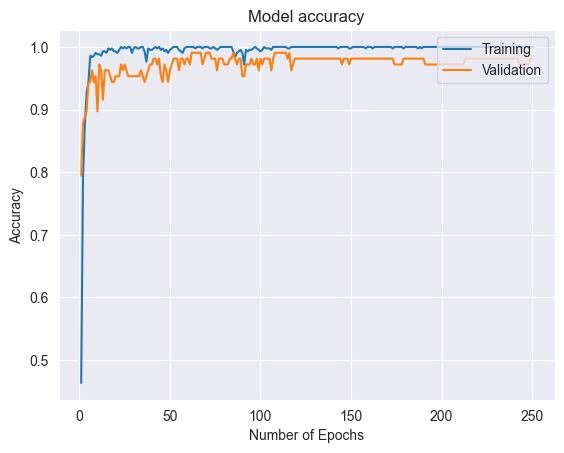

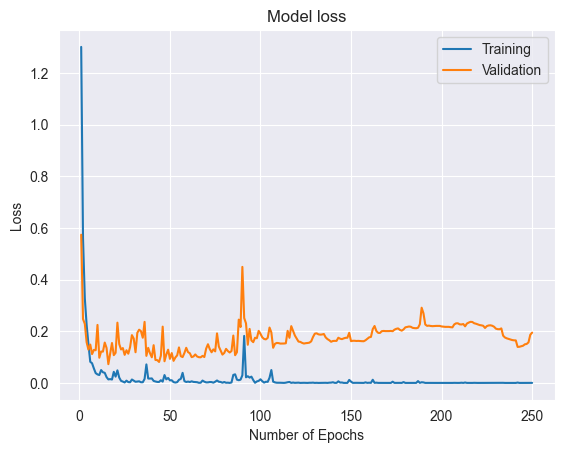

In [66]:
def plot_learningCurve(history, epochs):
    # Plotting the accuracy graph of training & validation
    epoch_range = range(1, epochs + 1)
    plt.plot(epoch_range, history.history["accuracy"])
    plt.plot(epoch_range, history.history["val_accuracy"])
    plt.title("Model accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Number of Epochs")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()

    # Plotting the loss graph of training & validation
    plt.plot(epoch_range, history.history["loss"])
    plt.plot(epoch_range, history.history["val_loss"])
    plt.title("Model loss")
    plt.ylabel("Loss")
    plt.xlabel("Number of Epochs")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()


plot_learningCurve(history, 250)

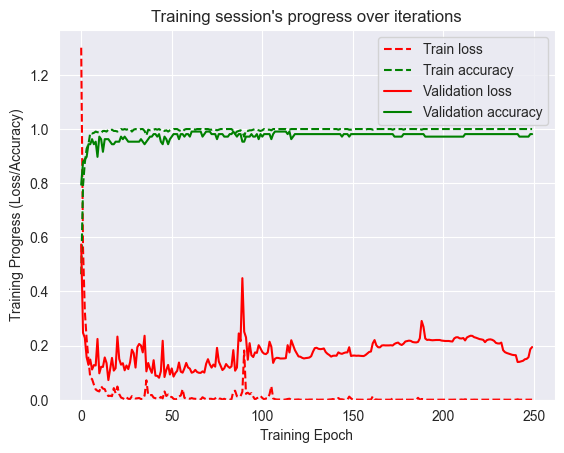

In [67]:
plt.plot(np.array(history.history["loss"]), "r--", label="Train loss")
plt.plot(np.array(history.history["accuracy"]), "g--", label="Train accuracy")
plt.plot(np.array(history.history["val_loss"]), "r-", label="Validation loss")
plt.plot(
    np.array(history.history["val_accuracy"]),
    "g-",
    label="Validation accuracy",
)
plt.title("Training session's progress over iterations")
plt.legend(loc="upper right")
plt.ylabel("Training Progress (Loss/Accuracy)")
plt.xlabel("Training Epoch")
plt.ylim(0)
plt.show()

In [68]:
def print_confusion_matrix(confusion_matrix, class_names, figsize=(10, 7), fontsize=14):
    df_cm = pd.DataFrame(confusion_matrix, index=class_names, columns=class_names)
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must not be integers.")
    heatmap.yaxis.set_ticklabels(
        heatmap.yaxis.get_ticklabels(),
        rotation=0,
        ha="right",
        fontsize=fontsize,
    )
    heatmap.xaxis.set_ticklabels(
        heatmap.xaxis.get_ticklabels(),
        rotation=45,
        ha="right",
        fontsize=fontsize,
    )
    plt.ylabel("Truth")
    plt.xlabel("Prediction")


truth = ["Downstairs", "Jogging", "Sitting", "Standing", "Upstairs", "Walking"]
prediction = [
    "Downstairs",
    "Jogging",
    "Sitting",
    "Standing",
    "Upstairs",
    "Walking",
]

187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(<Figure size 500x500 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

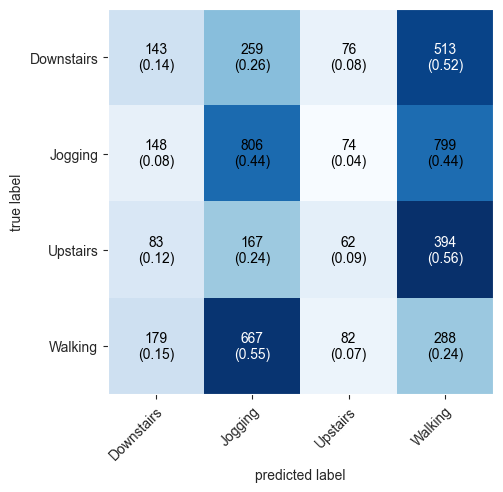

In [69]:
y_unimib_pred = np.argmax(model.predict(X_unimib), axis=-1)

shared_class_names = [
    "Downstairs",
    "Jogging",
    "Upstairs",
    "Walking",
]

shared_class_ids = [
    wisdm_class_to_id[class_name]
    for class_name in shared_class_names
]

mat = confusion_matrix(
    y_unimib,
    y_unimib_pred,
    labels=shared_class_ids,
)

plot_confusion_matrix(
    conf_mat=mat,
    class_names=shared_class_names,
    show_normed=True,
    figsize=(5, 5),
)

In [70]:
print("Precision Score : ", precision_score(y_test, y_pred, average=None))
print("Recall Score : ", recall_score(y_test, y_pred, average=None))
print("Accuracy Score :", accuracy_score(y_test, y_pred, normalize=True))
print("Loss Score :", hamming_loss(y_test, y_pred))

Precision Score :  [1.  1.  1.  0.9 1.  1. ]
Recall Score :  [1.         0.94444444 1.         1.         1.         0.94117647]
Accuracy Score : 0.9813084112149533
Loss Score : 0.018691588785046728
